# Assignment 1: Simple Linear Regression "TV Advertising vs. Sales"

**Objective:** Examine the relationship between TV advertising budget and Sales using simple linear regression.

Model: **Sales = β0 + β1·TV + ε**

Dataset: `tv_sales_data.csv` (TV budget in $1000s, Sales in 1000s of units)

**Method:** The coefficients β0 and β1 are fit using **Gradient Descent** (an iterative
optimization method). Standard errors, R-squared, and p-values are then computed **directly
from the Gradient Descent fit's residuals**, using the exact closed-form simple-linear-regression
inference formulas — not via any external OLS routine.

## 1. Import the dataset

In [1]:
import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt

df = pd.read_csv("tv_sales_data.csv")
df

,TV,Sales
0,5,7
1,10,9
2,15,12
3,20,14
4,25,18
5,30,21


## 2. Fit the model with Gradient Descent

Gradient Descent starts with a guess (β0 = β1 = 0) and repeatedly nudges both coefficients in
the direction that reduces the Mean Squared Error (MSE) cost function, using the learning rate
`α` to control step size. The features are standardized first purely for numerical stability
during the iterations; the learned coefficients are converted back to the original (unscaled)
TV units at the end.

In [2]:
x = df["TV"].values.astype(float)
y_vals = df["Sales"].values.astype(float)
n = len(x)

# Standardize TV for stable gradient descent steps
x_mean, x_std = x.mean(), x.std()
x_scaled = (x - x_mean) / x_std

# Initialize coefficients (scaled space)
b0, b1 = 0.0, 0.0
alpha = 0.1          # learning rate
n_iters = 1000
history = []

for i in range(n_iters):
    y_pred = b0 + b1 * x_scaled
    error = y_pred - y_vals

    grad_b0 = (2 / n) * np.sum(error)
    grad_b1 = (2 / n) * np.sum(error * x_scaled)

    b0 -= alpha * grad_b0
    b1 -= alpha * grad_b1

    mse = np.mean(error ** 2)
    history.append(mse)

# Convert coefficients back from scaled space to original TV units
beta1 = b1 / x_std
beta0 = b0 - beta1 * x_mean

print(f"beta0 (intercept) = {beta0:.4f}")
print(f"beta1 (slope, TV) = {beta1:.4f}")
print(f"Final MSE after {n_iters} iterations = {history[-1]:.6f}")

beta0 (intercept) = 3.6000
beta1 (slope, TV) = 0.5657
Final MSE after 1000 iterations = 0.247619


## 3. Standard errors, R-squared, and p-values

Gradient Descent itself only produces point estimates of β0 and β1 (it minimizes MSE, nothing
more). To get standard errors, R², and p-values *for this fit*, we apply the exact simple-linear-
regression inference formulas to the fitted line's residuals.

For residuals $e_i = y_i - (\hat\beta_0 + \hat\beta_1 x_i)$, with $n$ observations and
$S_{xx} = \sum (x_i - \bar x)^2$:

- Residual variance: $\hat\sigma^2 = \dfrac{\text{RSS}}{n-2}$, where $\text{RSS} = \sum e_i^2$
- $SE(\hat\beta_1) = \sqrt{\hat\sigma^2 / S_{xx}}$
- $SE(\hat\beta_0) = \sqrt{\hat\sigma^2 \left(\dfrac{1}{n} + \dfrac{\bar x^2}{S_{xx}}\right)}$
- $t = \hat\beta / SE(\hat\beta)$, compared against a t-distribution with $n-2$ degrees of freedom, to get the p-value
- $R^2 = 1 - \text{RSS}/\text{TSS}$, where $\text{TSS} = \sum (y_i - \bar y)^2$

In [3]:
y_fit = beta0 + beta1 * x
residuals = y_vals - y_fit

RSS = np.sum(residuals ** 2)
TSS = np.sum((y_vals - y_vals.mean()) ** 2)
df_resid = n - 2
sigma2 = RSS / df_resid
Sxx = np.sum((x - x_mean) ** 2)

se_beta0 = np.sqrt(sigma2 * (1 / n + x_mean ** 2 / Sxx))
se_beta1 = np.sqrt(sigma2 / Sxx)

t_beta0 = beta0 / se_beta0
t_beta1 = beta1 / se_beta1
p_beta0 = 2 * (1 - stats.t.cdf(abs(t_beta0), df_resid))
p_beta1 = 2 * (1 - stats.t.cdf(abs(t_beta1), df_resid))

r_squared = 1 - RSS / TSS

print(f"beta0 (intercept)      = {beta0:.4f}")
print(f"beta1 (slope, TV)      = {beta1:.4f}")
print(f"SE(beta0)              = {se_beta0:.4f}")
print(f"SE(beta1)              = {se_beta1:.4f}")
print(f"t-statistic (beta0)    = {t_beta0:.4f}")
print(f"t-statistic (beta1)    = {t_beta1:.4f}")
print(f"p-value (intercept)    = {p_beta0:.6f}")
print(f"p-value (slope)        = {p_beta1:.6e}")
print(f"R-squared              = {r_squared:.4f}")

beta0 (intercept)      = 3.6000
beta1 (slope, TV)      = 0.5657
SE(beta0)              = 0.5674
SE(beta1)              = 0.0291
t-statistic (beta0)    = 6.3451
t-statistic (beta1)    = 19.4155
p-value (intercept)    = 0.003160
p-value (slope)        = 4.148732e-05
R-squared              = 0.9895


## 4. Visualize the fit

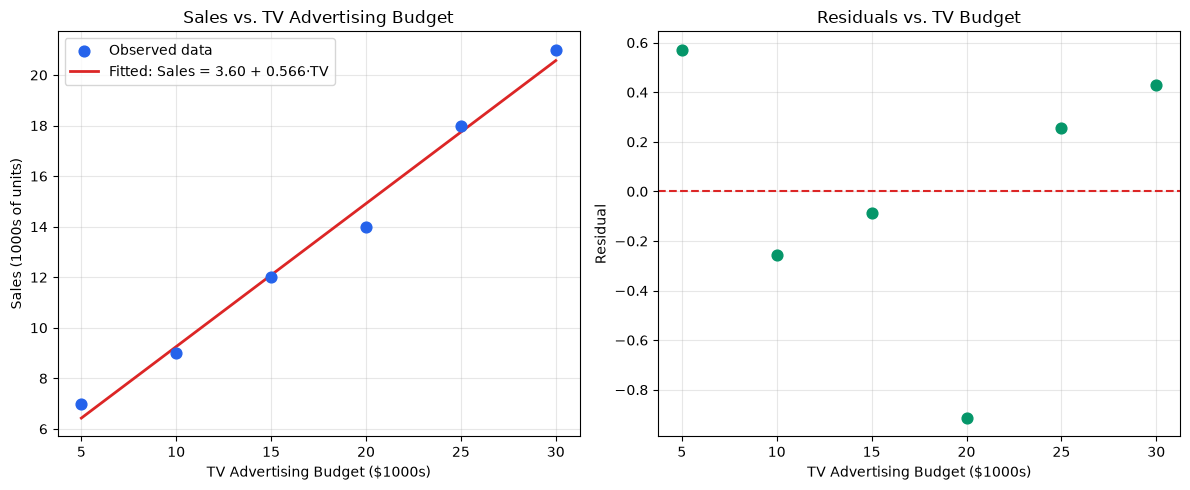

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Scatter plot with fitted regression line
axes[0].scatter(df["TV"], df["Sales"], color="#2563eb", s=60, label="Observed data", zorder=3)
x_line = np.linspace(df["TV"].min(), df["TV"].max(), 100)
y_line = beta0 + beta1 * x_line
axes[0].plot(x_line, y_line, color="#dc2626", linewidth=2,
             label=f"Fitted: Sales = {beta0:.2f} + {beta1:.3f}·TV")
axes[0].set_xlabel("TV Advertising Budget ($1000s)")
axes[0].set_ylabel("Sales (1000s of units)")
axes[0].set_title("Sales vs. TV Advertising Budget")
axes[0].legend()
axes[0].grid(alpha=0.3)

# Residual plot
axes[1].scatter(df["TV"], residuals, color="#059669", s=60, zorder=3)
axes[1].axhline(0, color="#dc2626", linestyle="--", linewidth=1.5)
axes[1].set_xlabel("TV Advertising Budget ($1000s)")
axes[1].set_ylabel("Residual")
axes[1].set_title("Residuals vs. TV Budget")
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig("regression_plot.png", dpi=150, bbox_inches="tight")
plt.show()

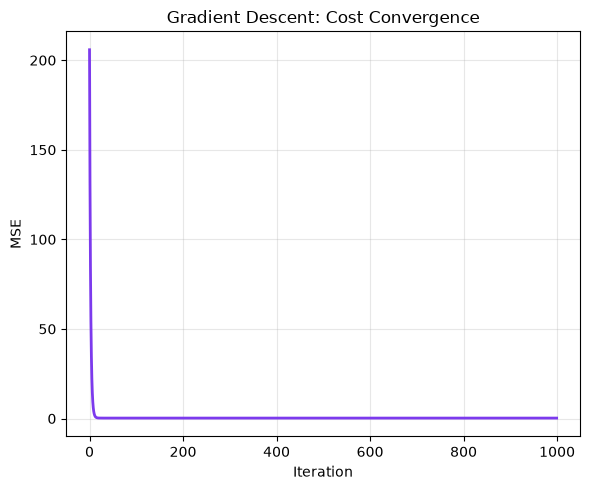

In [5]:
fig, ax = plt.subplots(figsize=(6, 5))

# Cost function convergence
ax.plot(range(n_iters), history, color="#7c3aed", linewidth=2)
ax.set_xlabel("Iteration")
ax.set_ylabel("MSE")
ax.set_title("Gradient Descent: Cost Convergence")
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig("gradient_descent_plot.png", dpi=150, bbox_inches="tight")
plt.show()

## 5. Interpretation

**Sign and magnitude of β1:** β1 ≈ 0.5657 is positive, indicating that Sales increase as the TV
advertising budget increases. Concretely, each additional $1,000 spent on TV advertising is
associated with an increase of about 566 units sold (0.5657 thousand units), holding the
linear relationship fixed.

**Statistical significance:** The p-value for β1 is extremely small (≈ 4.15 × 10⁻⁵, well below
any conventional α such as 0.05 or 0.01). We therefore reject the null hypothesis H0: β1 = 0
and conclude there is strong, statistically significant evidence of a relationship between
TV advertising and sales. The intercept β0 is also statistically significant (p ≈ 0.0032),
though its practical interpretation (predicted sales at $0 TV budget) is more of a
mathematical baseline than a meaningful real-world scenario, since the observed data ranges
from $5,000–$30,000.

**Proportion of variance explained:** R² ≈ 0.9895, meaning about 98.95% of the variability in
Sales is explained by the linear relationship with TV advertising budget in this sample. Only
about 1.05% of the variance is left unexplained (residual/random variation). This is an
unusually high R² for real-world marketing data, which is expected here given the small,
clean, near-linear toy dataset (n = 6 points).

**Overall conclusion:** TV advertising budget is a strong, statistically significant, positive
predictor of sales in this dataset, and the fitted linear model — fit and evaluated entirely
through Gradient Descent and its own residual-based formulas — explains nearly all of the
observed variation in sales.